In [ ]:
#Jnomics Media - Data Analysis Test - TASK 2: Cohort Analysis
#by Hanif Maulana Abdullah

#TASK 3.1 Compute retention rate at months 1, 2, 3, and 6

In [ ]:
#TASK 3.1 Compute retention rate at m-1, 2, 3, 6
#using subscriptions csv
#import library and csv
import pandas as pd #for table
pd.set_option('display.expand_frame_repr', False) #to show dataframe in fully horizontal (no wrap)

#import subscriptions csv data
url_subs="https://drive.google.com/uc?export=download&id=1zOerxqcMLhEChUNOMQQpKLuUThsQZ1I0"
df_subs=pd.read_csv(url_subs) #read csv file as dataFrame

#create filter: we will work only for start_date at min. 1 Apr 2025
df_filt = df_subs[(df_subs['start_date'] >= '2025-04-01')]
#print(df_filt)

#erase every multiplicated user_id, we only use the newest end_date
sorted_filt = df_filt.sort_values(by='start_date')
cleaned_filt = sorted_filt.drop_duplicates(subset='user_id', keep='first')
#print(cleaned_filt)

#make sure dataframe lists format are datetime, so math operations can work
cleaned_filt['start_date'] = pd.to_datetime(cleaned_filt['start_date'])
cleaned_filt['end_date'] = pd.to_datetime(cleaned_filt['end_date'])

#create new list: start_month, end_month
cleaned_filt2 = cleaned_filt.copy()
cleaned_filt2['start_month'] = pd.to_datetime(cleaned_filt['start_date']).dt.to_period('M')
cleaned_filt2['end_month'] = pd.to_datetime(cleaned_filt['end_date']).dt.to_period('M')
#print(cleaned_filt2)

#create new dataframe: user_id, start_month, end_month
start_end = cleaned_filt2[['user_id', 'start_month', 'end_month']].reset_index()
#print(start_end)

#replace NaT in 'end_month' with 2026-03 (last month in given period)
start_end2 = start_end.copy()
max_month = start_end['end_month'].max()
start_end2['end_month'] = start_end['end_month'].fillna(max_month)
#print(start_end2)

#check overall retention for month-[1, 2, 3, 6], which users are still active?
active_stat = start_end2.copy() #duplicate new dataframe
for n in [0, 1, 2, 3, 6]:
  active_stat['target_month'] = active_stat['start_month'] + n #define parameter, month_start + n
  active_stat[f'm-{n}'] = (active_stat['end_month'] >= active_stat['target_month']).astype(int)
  #column of active users in month-i: True=1 and False=0
  rate = active_stat[f'm-{n}'].mean()*100 #return retention rate: mean of 0 and 1
  rate = rate.round(2)
  #print('retention rate in month-', n, 'is:', rate, '%')

#print(active_stat)

#make list of m-1,2,3,6 column
cols = []
for n in [1, 2, 3, 6]:
  cols.append(f'm-{n}')

#groupby 'm-1,2,3,6 per 'start_month' (sum/count)
month_stat = active_stat.groupby('start_month')[cols].sum().reset_index()
month_stat['start_month'] = month_stat['start_month'].dt.to_timestamp().dt.strftime('%b %y')
#print(month_stat)

#groupby 'm-1,2,3,6 per 'start_month' (retention rate)
month_ret = (active_stat.groupby('start_month')[cols].mean()*100).round(2).reset_index()
month_ret['start_month'] = month_ret['start_month'].dt.to_timestamp().dt.strftime('%b %y')
print('monthly retention rate (%)')
print(month_ret)

monthly retention rate (%)
   start_month     m-1    m-2    m-3    m-6
0       Apr 25  100.00  66.10  52.54  32.20
1       May 25   96.23  69.81  58.49  41.51
2       Jun 25  100.00  70.91  61.82  47.27
3       Jul 25   98.25  78.95  71.93  45.61
4       Aug 25  100.00  80.77  65.38  34.62
5       Sep 25  100.00  78.57  73.81  47.62
6       Oct 25  100.00  68.85  50.82   0.00
7       Nov 25  100.00  78.21  66.67   0.00
8       Dec 25  100.00  77.50  67.50   0.00
9       Jan 26  100.00  79.41   0.00   0.00
10      Feb 26  100.00   0.00   0.00   0.00
11      Mar 26    0.00   0.00   0.00   0.00


/tmp/ipykernel_6303/1681231801.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_filt['start_date'] = pd.to_datetime(cleaned_filt['start_date'])
/tmp/ipykernel_6303/1681231801.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_filt['end_date'] = pd.to_datetime(cleaned_filt['end_date'])


Retention rate for each cohort at months 1, 2, 3, and 6 can be seen on the dataframe above. For clearer insights, below is the heatmap.

#TASK 3.2 monthly_start Retention Heatmap

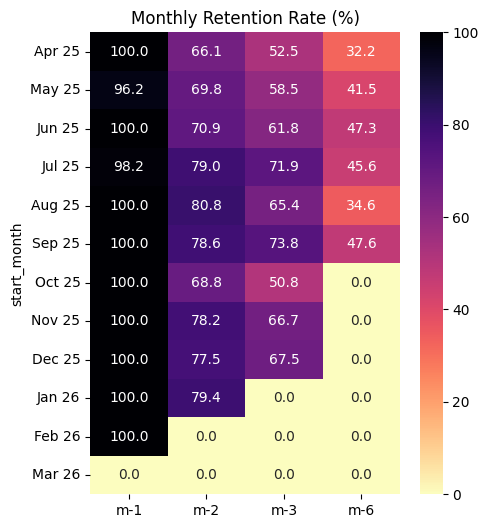

In [ ]:
#Task 3.2 build heatmap
#plotting
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = month_ret.set_index('start_month')

plt.figure(figsize=(5,6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='magma_r')
plt.title('Monthly Retention Rate (%)')
plt.show()

The heatmap shows similar pattern except for April and August 2025.

#TASK 3.3 Identify Underperformed Cohort

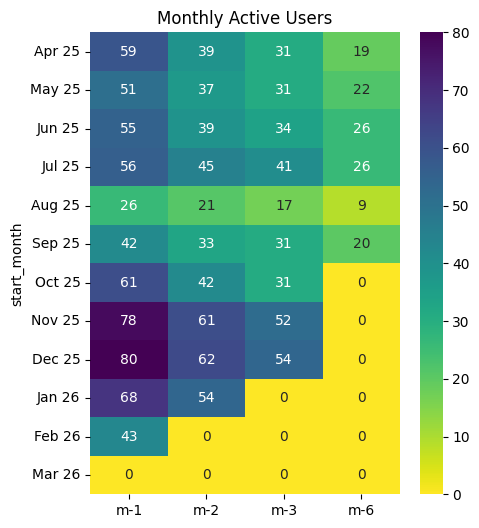

In [ ]:
#TASK 3.3. Identify Underperformed Cohort
#plotting
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = month_stat.set_index('start_month')

plt.figure(figsize=(5,6))
sns.heatmap(heatmap_data, annot=True, cmap='viridis_r')
plt.title('Monthly Active Users')
plt.show()

As seen in the "Monthly Retention Rate" heatmap above this section, it appears that April and August 2025 underperformed. However, if we create another heatmap for the number of active users per cohort, we'll see that the August 2025 cohort significantly underperformed. So what's really going on? Why are there so few of them? And why does their retention rate tend to be lower than other cohorts?

**Hypothesis 1**
Columns M-1 (and M-0) show that the number of active users in August 2025 is very low compared to other cohorts. It is possible that marketing strategies in August and the previous month were suboptimal.

**Solution 1**
Check acquisition source data to see which sources have decreased. Since the data and analysis are already available, it appears that referrals have decreased significantly from June to September 2025, so this may be a factor. Further analysis can be conducted by including new subscriptions in August 2025 originating from referrals and comparing them with other sources and the previous period.

**Hypothesis 2**
Column M-6 (February 2026) shows a very contrasting color, indicating a significant decrease in retention rates in the August 2025 cohort. I assume this is related to a decrease in the quality of subscription content.

**Solution 2**
Check the quantitative engagement data for total time spent. Analyze data from December 2025, January 2026, and February 2026 (M-4, M-5, M,6) to compare the total 'time_spent', whether there is a decrease in engagement which is an indication that there is a problem in the quality of subscription content.